In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
## column clean

df.columns = pd.Series(df.columns).str.lower()
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [31]:
df.isnull().sum().sort_values(ascending = False)

cabin          687
age            177
embarked         2
passengerid      0
name             0
pclass           0
survived         0
sex              0
parch            0
sibsp            0
fare             0
ticket           0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
survived_count = df["survived"].value_counts()
survived_count

survived
0    549
1    342
Name: count, dtype: int64

In [34]:
##Survived distribution
df["survived"].value_counts(normalize = True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

# SURVIVAL DISTRIBUTION

C:\Users\karim\AppData\Local\Temp\ipykernel_544\1862461842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='Set2')


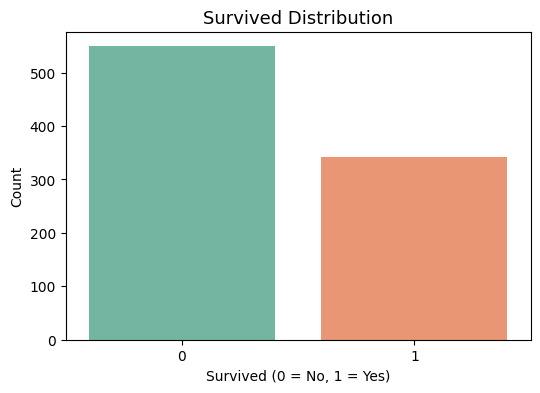

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df, palette='Set2')
plt.title("Survived Distribution", fontsize=13)
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.savefig("../Reports/Figures/survival_Distribution(bar).png")
plt.show()

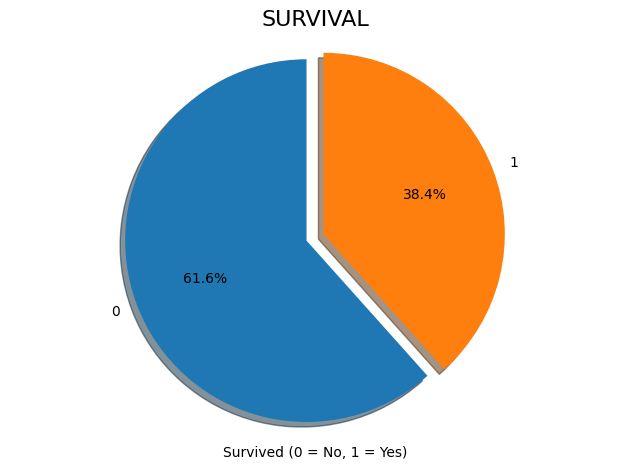

In [36]:
plt.pie(survived_count , labels = survived_count.index,autopct = '%.1f%%',
         startangle = 90, shadow= True, explode =[0.05] * len(survived_count))
plt.title("SURVIVAL", fontsize = 16)
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt .axis("equal")
plt.tight_layout()
plt.savefig("../Reports/Figures/survival_Distribution(pie).png")
plt.show()


In [37]:
# Group by sex and calculate mean of survived
survival_rate_by_sex = df.groupby("sex")["survived"].mean()

print(survival_rate_by_sex)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


C:\Users\karim\AppData\Local\Temp\ipykernel_544\2658025795.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_rate_by_sex.index, y=survival_rate_by_sex.values, palette="Set2")


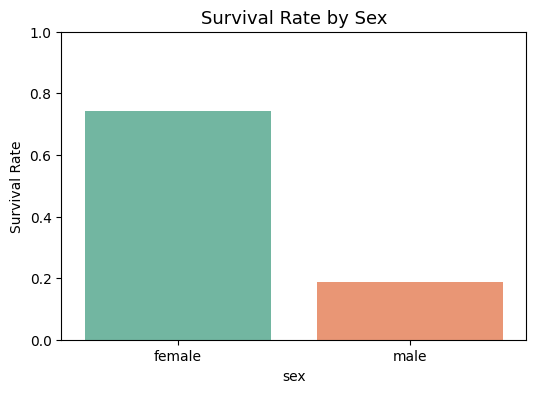

In [38]:
plt.figure(figsize=(6,4))
sns.barplot(x=survival_rate_by_sex.index, y=survival_rate_by_sex.values, palette="Set2")
plt.title("Survival Rate by Sex", fontsize=13)
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.savefig("../Reports/Figures/survival_by_sex.png")
plt.show()

In [39]:
survival_rate_by_pclass = df.groupby("pclass")["survived"].mean()

print(survival_rate_by_pclass)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


C:\Users\karim\AppData\Local\Temp\ipykernel_544\2411945024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_rate_by_pclass.index, y=survival_rate_by_pclass.values, palette="bright")


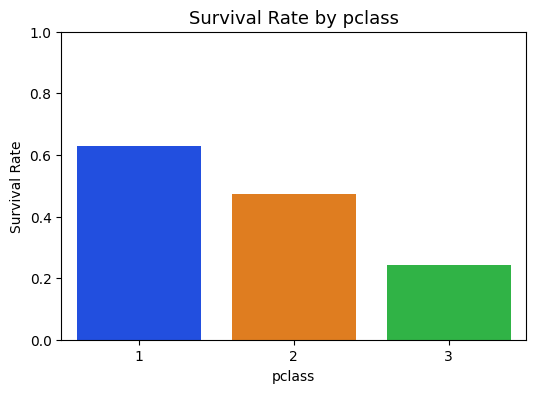

In [40]:
plt.figure(figsize=(6,4))
sns.barplot(x=survival_rate_by_pclass.index, y=survival_rate_by_pclass.values, palette="bright")
plt.title("Survival Rate by pclass", fontsize=13)
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.savefig("../Reports/Figures/survival_by_pclass.png")
plt.show()


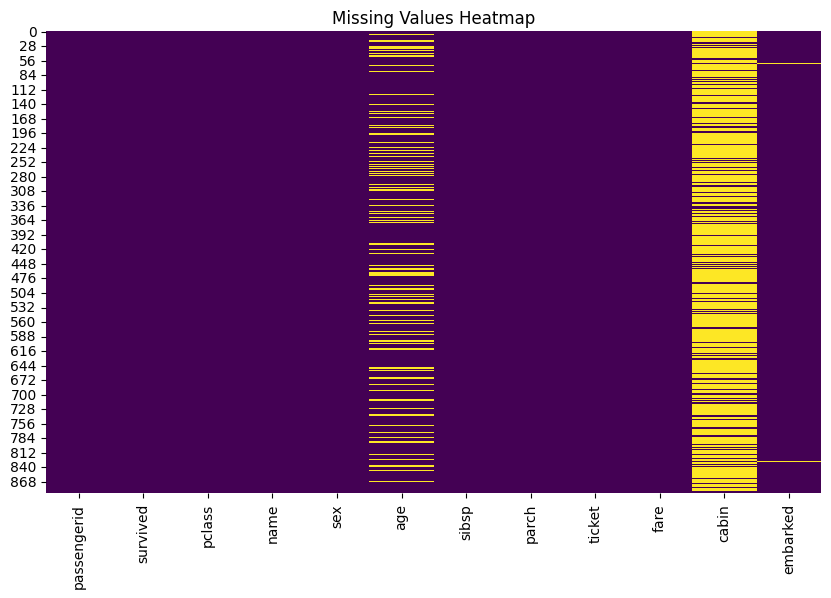

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.savefig("../Reports/Figures/missing_value_heatmap.png")
plt.show()

In [42]:
## we will drop cabin  from our data set as it will not have any effect due to more than 90 percent missing values

df = df.drop(columns=["cabin"])
df


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


## Report

- female have high survival rate
- 1st class had higher survival
- Age missingness needs imputation
- cabin column has no effect on data


In [48]:
df.to_csv("train_cleaned.csv", index=False)

In [49]:
df

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [51]:
df.isnull().sum().sort_values(ascending = False)

age            177
embarked         2
passengerid      0
pclass           0
survived         0
sex              0
name             0
sibsp            0
parch            0
ticket           0
fare             0
dtype: int64